# Data Exploration: Food Allergy Transcriptomics

This notebook is meant to explore RNA-seq data from GSE189149 exploring gene expression data from CD4+ T cells in food allergy vs healthy controls from Murdoch Children's Research Institute. This notebook is meant to experiment with analysis before classification. 

More info:
Tissue: Naive CD4+ T cells
Platform: Illumina NovaSeq 6000
Samples: 48 (allergic patients + non-allergic controls)

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/raw/GSE189149_counts_table.txt', sep='\t', index_col=0)

print("Shape:", df.shape)
print("\nFirst few sample names:", df.columns[:5].tolist())
print("\nFirst few gene names:", df.index[:5].tolist())

Shape: (20245, 48)

First few sample names: ['X2202_M_NA', 'X2207_F_NA', 'X3752_M_NA', 'X3762_M_NA', 'X3874_M_NA']

First few gene names: ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112']


In [4]:
labels = []
for col in df.columns:
    if col.endswith('_NA'):
        labels.append('Control')
    elif col.endswith('_PA'):
        labels.append('Peanut_Allergic')
    elif col.endswith('_MA'):
        labels.append('Multi_Allergic')

metadata = pd.DataFrame({
    'sample': df.columns,
    'whole group': labels
})

print(metadata['whole group'].value_counts())

whole group
Control            18
Multi_Allergic     17
Peanut_Allergic    13
Name: count, dtype: int64


In [6]:
# Now, since we're just making a classifier, let's try to create a dataframe with just controls and allergic patients:
metadata['simple_group'] = metadata['whole group'].apply(
    lambda x: 'Control' if x == 'Control' else 'Allergic'
)

print(metadata['simple_group'].value_counts())

simple_group
Allergic    30
Control     18
Name: count, dtype: int64


In [8]:
mkdir -p results

In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Transpose so samples are rows, genes are columns
X = df.T

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
colors = {'Control': 'steelblue', 'Allergic': 'tomato'}
plt.figure(figsize=(8, 6))
for group in ['Control', 'Allergic']:
    idx = [i for i, g in enumerate(metadata['binary_group']) if g == group]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                label=group, color=colors[group], alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of GSE189149: Food Allergy CD4+ T Cells')
plt.legend()
plt.tight_layout()
plt.savefig('results/pca_GSE189149.png', dpi=150)
plt.show()

DuplicateError: Expected unique column names, got:
- 'Mar-02' 2 times
- 'Mar-01' 2 times

In [10]:
print(df.index[df.index.duplicated(keep=False)].tolist())

['Mar-02', 'Mar-02', 'Mar-01', 'Mar-01']


In [11]:
df.index = df.index.where(~df.index.duplicated(), df.index + '_dup')

print("Duplicates after fix:", df.index.duplicated().sum())

Duplicates after fix: 0


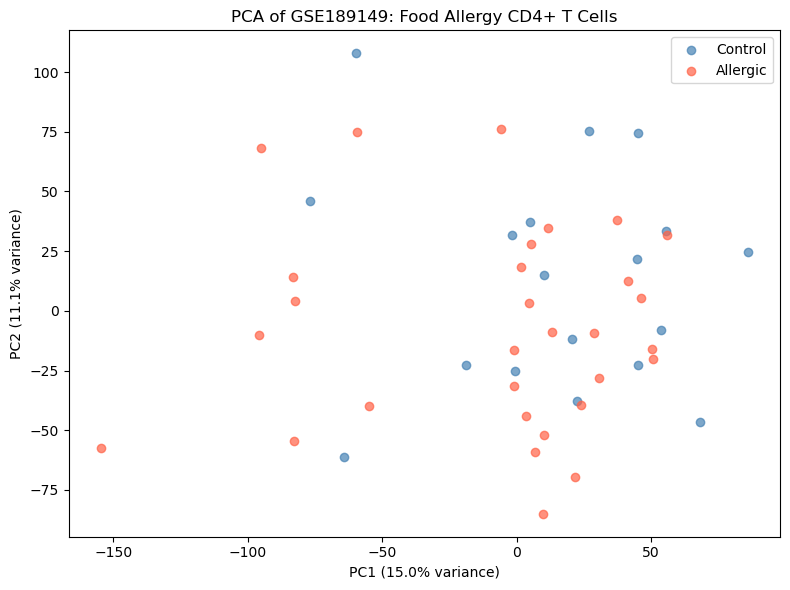

In [14]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Transpose so samples are rows, genes are columns
X = df.T

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
colors = {'Control': 'steelblue', 'Allergic': 'tomato'}
plt.figure(figsize=(8, 6))
for group in ['Control', 'Allergic']:
    idx = [i for i, g in enumerate(metadata['simple_group']) if g == group]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                label=group, color=colors[group], alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of GSE189149: Food Allergy CD4+ T Cells')
plt.legend()
plt.tight_layout()
plt.savefig('results/pca_GSE189149.png', dpi=150)
plt.show()

In [15]:
# Check how many samples fall into either condition

print("Total samples in counts table:", len(df.columns))
print("Sample names:", df.columns.tolist())

Total samples in counts table: 48
Sample names: ['X2202_M_NA', 'X2207_F_NA', 'X3752_M_NA', 'X3762_M_NA', 'X3874_M_NA', 'X4219_F_NA', 'X4502_M_NA', 'X4730_F_NA', 'X5603_M_NA', 'X5827_M_NA', 'X6341_F_NA', 'X6398_M_NA', 'X7034_M_NA', 'X7076_F_NA', 'X7346_F_NA', 'X7414_M_NA', 'X7524_M_NA', 'X8977_F_NA', 'X10540_F_PA', 'X1728_M_PA', 'X1847_M_PA', 'X2065_F_PA', 'X4366_M_PA', 'X4872_M_PA', 'X5868_M_PA', 'X6081_M_PA', 'X7019_M_PA', 'X7022_M_PA', 'X7087_F_PA', 'X8798_F_PA', 'X9470_M_PA', 'X1337_M_MA', 'X1535_M_MA', 'X1794_M_MA', 'X2131_F_MA', 'X2138_F_MA', 'X2627_M_MA', 'X2712_M_MA', 'X4189_F_MA', 'X4389_M_MA', 'X4413_M_MA', 'X4759_F_MA', 'X566_F_MA', 'X5757_F_MA', 'X7426_F_MA', 'X7525_F_MA', 'X8072_M_MA', 'X9620_F_MA']


In [16]:
print(df)

               X2202_M_NA  X2207_F_NA  X3752_M_NA  X3762_M_NA  X3874_M_NA  \
TSPAN6           0.342171    0.420256    0.400857    0.000000    0.000000   
TNMD             0.000000    0.000000    0.000000    0.000000    0.000000   
DPM1            34.559232   37.402795   31.400480   35.929355   40.832701   
SCYL3           24.294113   26.756306   29.797051   23.130486   18.479033   
C1orf112        11.633801   12.607684   11.357620   12.490463   11.623908   
...                   ...         ...         ...         ...         ...   
RP11-1084J3.4    0.000000    0.000000    0.000000    0.000000    0.000000   
RP11-944L7.5     0.000000    0.000000    0.000000    0.000000    0.000000   
FLJ00388         0.000000    0.000000    0.000000    0.000000    0.000000   
RP11-474G23.1    0.000000    0.000000    0.000000    0.000000    0.000000   
AC005358.1       0.000000    0.000000    0.000000    0.000000    0.000000   

               X4219_F_NA  X4502_M_NA  X4730_F_NA  X5603_M_NA  X5827_M_NA  

In [20]:
cd /Neuro-allergy-Classifier
git add
git commit -m "Add data exploration notebook with PCA of GSE189149"
git push origin main

SyntaxError: invalid syntax (766986185.py, line 2)